# Week 1: Introduction to Feedforward Neural Networks

The basic building blocks of a neural network:
- <b>nodes </b> -  abstract neuron-inspired variables whose current time-varying activation value reflects the network's current "representational states".
- <b>activation </b> functions - non-linear transformations on each node's activation value

A <b><i> layer </b></i> is a population of nodes at the same stage of information processing --- they receive inputs from a preceding population (layer) and pass outputs to a subsequent population (layer)

- <b>weights </b> - nXm matrix of <i>n</i> inputs and <i>m </i> outputs that connects nodes between layers. conventionally, where knowledge is stored in a feedforward network)

- <b>biases</b>  - terms that are added to the weighted input of each node



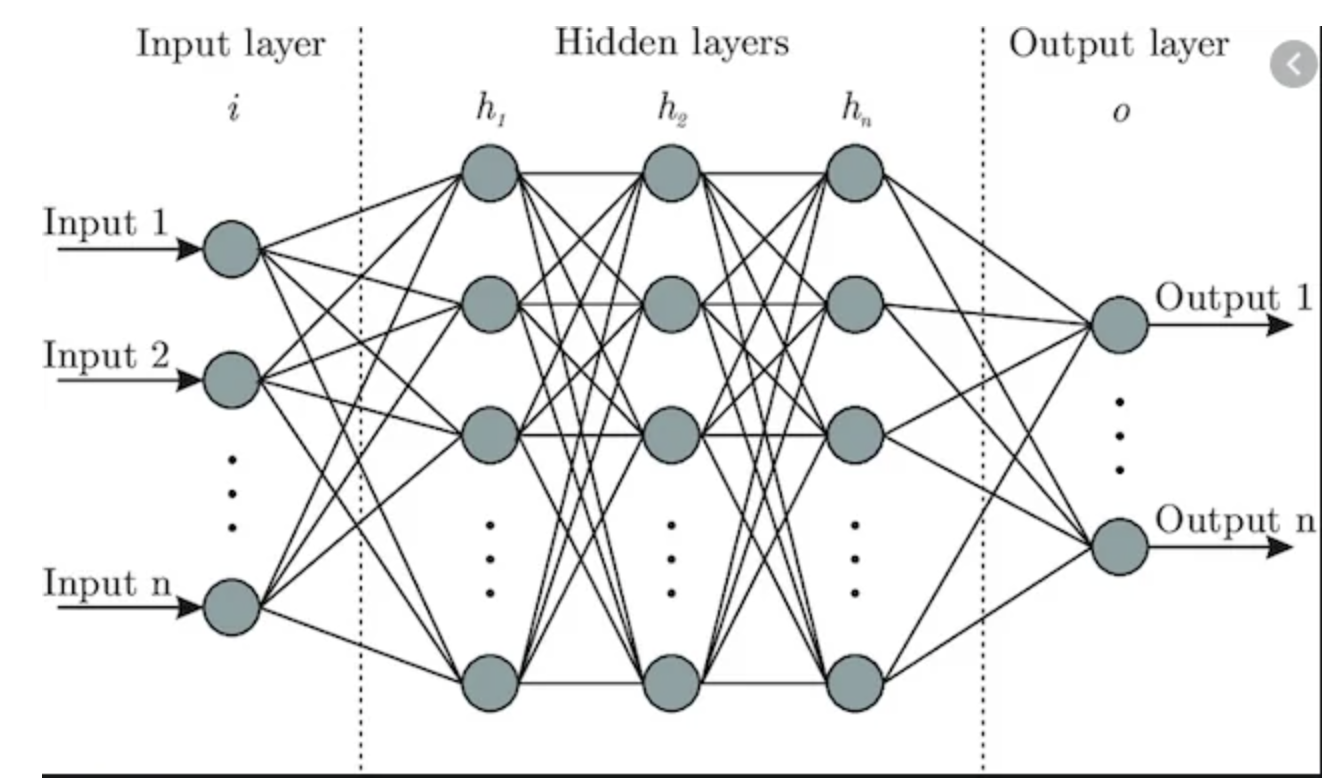




Learning vs. Processing ("inference")
- <b> how they learn </b> (changing the weights/biases to optimize the loss function<)
    - <b> objective ("loss/cost") function </b>: (what does the system seek to achieve?)
      *   minimized by changing the weights via gradient descent
      *   backpropagation is the algorithm by which gradient descent is implemented in deep neural networks




- <b> how they process information ("inference") </b> (normally after learning, changing the weights/activity states to perform some task

  - in inference, information flows "forward" for processing.
  - in learning, information flows "backward" to update the model's understanding of the data/world.

 Learning is fundamentally about <b>reliably changing some physical state to reflect the structure of the world/data</b>.



Networks are <i> compositions </i> of functions.

$$
 f(g(x))
$$

The more compositions, the "deeper", the neural network.

$$
f'(g'(f(g(x))))
$$


$$
f''(g''(f'(g'(f(g(x))))))
$$

$$
...
$$



For input data <b><i>x</b></i>, code <b><i>z</b></i>, and output <b><i>y</b></i>
 $$ X \rightarrow Z \rightarrow Y $$



*  <b>Categorization</b>, when y is a <i> class </i>,
*  <b>Action Selection</b>, when y is an <i> action </i>.
*  <b>Prediction</b>, when y is a  <i> future state </i>
*   <b> Data compression </b>, when is y the <i> currently available data </i>.


<b> Representational Space </b>. A common idea that we will frequently return to is a "representational space". Imagine that the nodes in a layer of a network are the <i>dimensions</i> of a space. Each input that is processed will be located a particular point in that space.

 To visualize this space, it is often necssary to compress it into 2D (or maybe 3D)

But, although we can't visualize high-dimensional spaces, the same principle of similarity (i.e., distance between points) applies to layers with high-dimensionality.


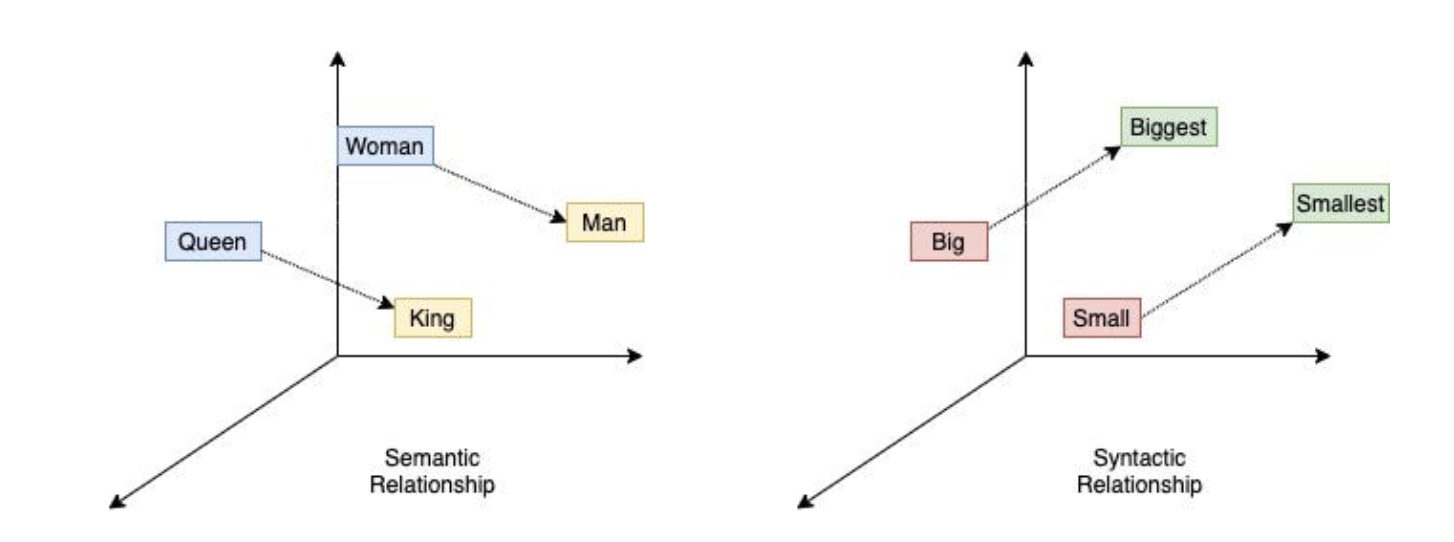

 Some Common Architectures
  e.g.,
  - feedforward (multi-layer perceptron)
  - recurrent
  - convolutional layer
  - external memories
  - self-attention
  - deep/shallow
  - ... your idea?


## Exploring an auto-encoder


An "autoencoder" is type of neural network: it seeks to <b> reconstruct </b> the data it receives, normally requiring that the data pass through a "bottleneck" (i.e., a low dimensional space).

The weights throughout the network are updated so that the network's reconstructions (<b>x'</b>) look increasingly like the input data <b>x</b> ("self-supervised").


<b>Why should we care about simply <i>re-constructing</i> the input data?</b>


In "Principles of Psychology" (1890) William James famously wrote:

 <i>"The baby, assailed by eyes, ears, nose, skin, and entrails at once, feels it all as one great blooming, buzzing confusion." (chapter 13, discrimination and comparison).</i>


How might physical systems might tame James' "blooming, buzzing, confusion"?

<!-- In principle, this "learning" could occur
  - <i>ontogenetically</i> -- over an individual's development. The empiricist position in philosophy favors knowledge acquisition over an individual's development.
  - <i>phylogenetically</i> -- over a species' evolution. The nativist tradition in philosophy emphasizes the importance of innate knowledge.
  - <i>or both</i>! inductive biases can speed learning, given experience. -->

Given the statistical complexity of the world, we often want to learn <b> simpler representations </b> -- i.e., only those features of the world that are going to be useful in the future.

<b>Occam's Razor </b>: Simpler models of the data are preferable, all else being equal. This idea underlies data compression in computer science, as well a statistics.

The structure of the auto-encoder --- learning to reconstruct the data, given limited representational resources --- forces the learning of simpler representations, by virtue of force the data through a bottleneck that must have sufficient information to re-generate the data.


## An Auto-Encoder in Pytorch

In [1]:

#this is for dealing w/ vectors, matrices etc. in numpy.
import numpy as np

#these are "pytorch" functions. pytorch contains a lot of established neural net functionality.
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
from torch.utils.data import Subset
import torchvision

#this is for plotting results
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 200

#device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'

Here, we deal with the MNIST dataset. Although not the best dataset for human learning, we use MNIST here because it is ubiquitous in machine learning for benchmarking learning algorithms. Some other datasets that may be of interest are [omniglot](https://github.com/brendenlake/omniglot) --- handwritten characters, many novel, that are better suited to comparing human and machine learning--- and CIFAR, visual images with more complex statistical and categorical structure (also common in ML).


 We will explore learning to reconstruct each image, with an auto-encoder, as well as classifying the digit associated with each image. (In Machine Learning, the former problem is considered "unsupervised" or "self-supervised", while the latter "supervised").


Next, we define a few <i> classes </i> that we can use. We will later create <i>instances</i> of these classes.

The first is the <i> encoder </i>, which takes the input data <b>x</b> and maps it to some representation, which we will call <b>z</b>.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()
    #note: these values are specific to the sizes of the 28x28 MNIST dataset.
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)

  #forward function defines structure of the network
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
      #ReLu Activation Function: linear if positive, otherwise zero.
        x = F.relu(self.linear1(x))
        return self.linear2(x)

- <i> Forward Pass </i> -  the system runs the input data through each of its functions to make its best guess about the output. (inference/ information processing above). Before the weights/biases are trained, these guesses should be really bad!

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        #ReLu Activation Function
        z = F.relu(self.linear1(z))
        #Sigmoid Activation Function
        z = torch.sigmoid(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.Encoder = Encoder(latent_dims)
        self.Decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.Encoder(x)
        return self.Decoder(z)

This is the basic structure of information-processing in the network. For it to learn, we need to make <i> backward passes </i>

  - adjust the network parameters to minimize error in its guess. It does this by traversing backwards from the output, collecting the derivatives of the error with respect to the parameters of the functions (gradients), and optimizing those parameters using <i>gradient descent.</i>

  - In future classes, we will learn more about gradient descent and backpropagation, as well as other forms of optimization. For now, we gloss over the mechanics and simply ask pytorch to do the heavy lifting, iteratively updating the weights with each "batch" of training data, so as to minimize the loss function we have defined.


Here, the loss function is the mean squared error between the predicted targets (<b>x'</b>) and actual targets (<b>x</b>).

$$
 Loss_{MSE}  = \sum_{i=1}^{k}(x_i - \hat{x}_i)^2
$$


<!-- We will want to save our model.

def save_checkpoint(model, optimizer, save_path, epoch):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch
    }, save_path)


def load_checkpoint(model, optimizer, load_path):
    checkpoint = torch.load(load_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    
    return model, optimizer, epoch -->

In [ ]:
def train(autoencoder, data, epochs=1):
    results = []
    # this is our "optimizer"
    opt = torch.optim.SGD(autoencoder.parameters())
    for epoch in range(epochs):
        for x, y in data:
            x = x.to(device)  # GPU
            opt.zero_grad()

            # these are model predictions
            x_hat = autoencoder(x)

            # this is the mean squared error loss
            loss = ((x - x_hat)**2).sum()
            loss.backward()
            opt.step()
            results.append(loss.item())
            if len(results) % 1000 == 0:
                print(f'Step {len(results)}, Loss: {loss.item():.4f}')
    return autoencoder, results

In [ ]:

# Create datasets for training & testing, download if haven't already.

train_set = torchvision.datasets.MNIST('./data', train=True,transform=torchvision.transforms.ToTensor(), download=True)
test_set = torchvision.datasets.MNIST('./data', train=False,transform=torchvision.transforms.ToTensor(), download=True)

# Create data loaders for MNIST datasets; shuffle for training, not for validation
train_load = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True)
test_load = torch.utils.data.DataLoader(test_set, batch_size=16, shuffle=False)

# Report split sizes
print('Training set has {} examples'.format(len(train_set)))
print('Test set has {} examples'.format(len(test_set)))

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.27MB/s]

Training set has 60000 examples
Test set has 10000 examples


Let's first visualize some of the Digits we have loaded.

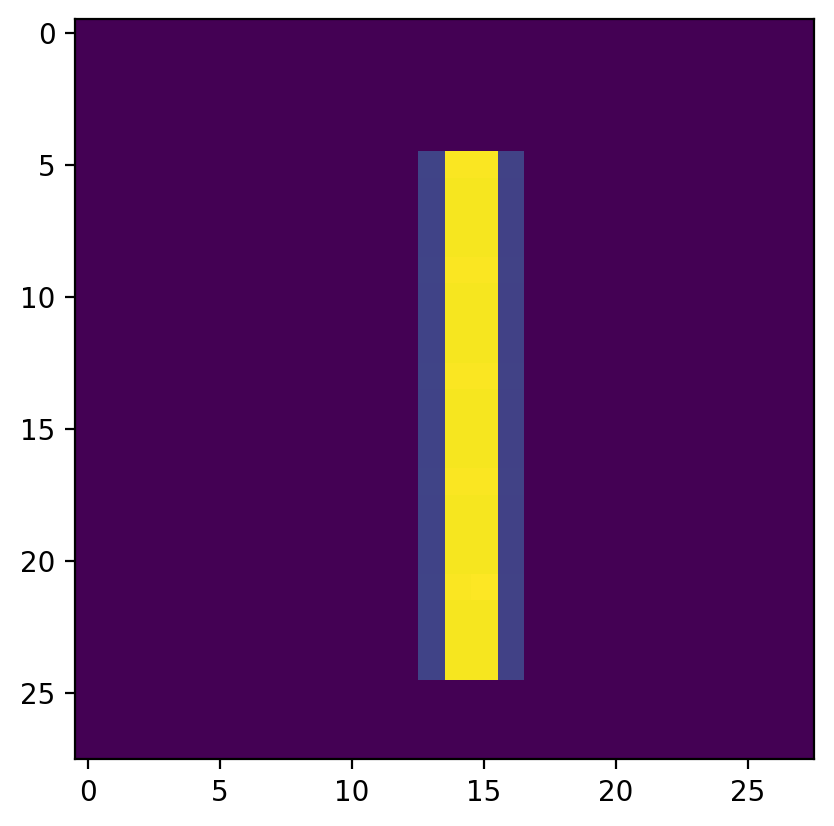

In [ ]:
imgTensor, labels = next(iter(train_load))
plt.imshow(imgTensor[2,0,:,:])
plt.show()

Look ok? Let's train an auto-encoder with a small number of nodes in the latent space <b>z</b>.

In [ ]:
# latent_dims: number of nodes in the latent space

latent_dims = 2
autoencoder = Autoencoder(latent_dims).to(device)
# epochs: number of passes
autoencoder, losses = train(autoencoder, train_set, epochs=1)

Step 1000, Loss: 43.3121
Step 2000, Loss: 43.9829
Step 3000, Loss: 44.3274
Step 4000, Loss: 45.2572
Step 5000, Loss: 43.9141
Step 6000, Loss: 25.7315
Step 7000, Loss: 29.5053
Step 8000, Loss: 68.0418
Step 9000, Loss: 32.7444
Step 10000, Loss: 20.9032
Step 11000, Loss: 63.7953
Step 12000, Loss: 57.8019
Step 13000, Loss: 27.8287
Step 14000, Loss: 32.8135
Step 15000, Loss: 19.9284
Step 16000, Loss: 13.8547
Step 17000, Loss: 22.2985
Step 18000, Loss: 56.2284
Step 19000, Loss: 32.4212
Step 20000, Loss: 48.2561
Step 21000, Loss: 33.2616
Step 22000, Loss: 25.2548
Step 23000, Loss: 28.1600
Step 24000, Loss: 52.0385
Step 25000, Loss: 18.4409
Step 26000, Loss: 47.8527
Step 27000, Loss: 31.5846
Step 28000, Loss: 41.8657
Step 29000, Loss: 45.7479
Step 30000, Loss: 18.0829
Step 31000, Loss: 27.3024
Step 32000, Loss: 46.9378
Step 33000, Loss: 45.2215
Step 34000, Loss: 33.5469
Step 35000, Loss: 23.5510
Step 36000, Loss: 29.3392
Step 37000, Loss: 41.1180
Step 38000, Loss: 45.8225
Step 39000, Loss: 30.

We can first look at the network's reconstructions after only one <i>epoch</i>.

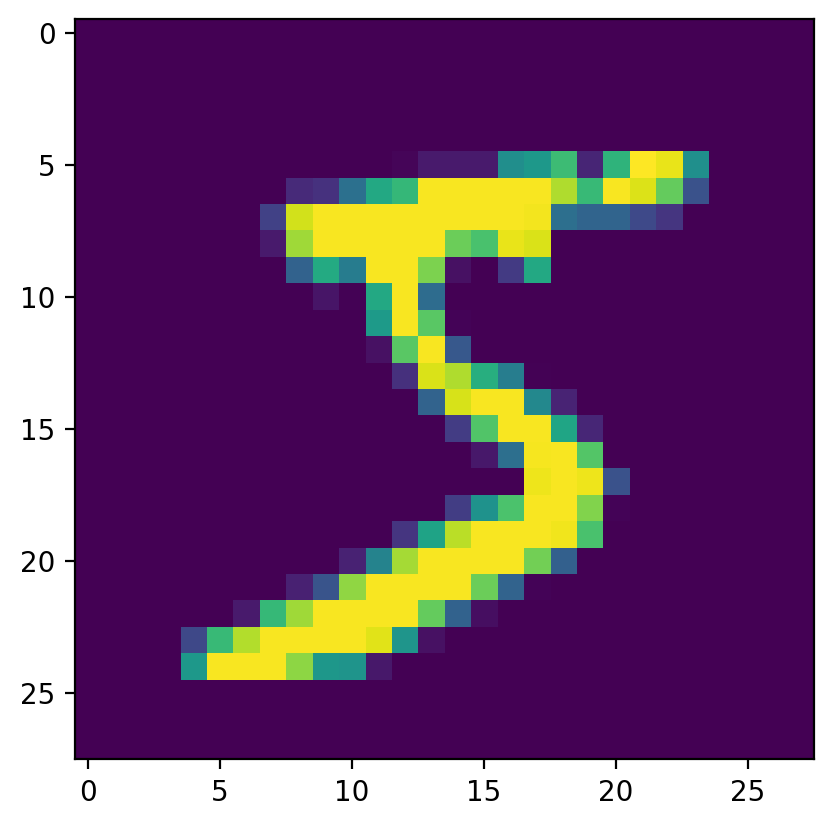

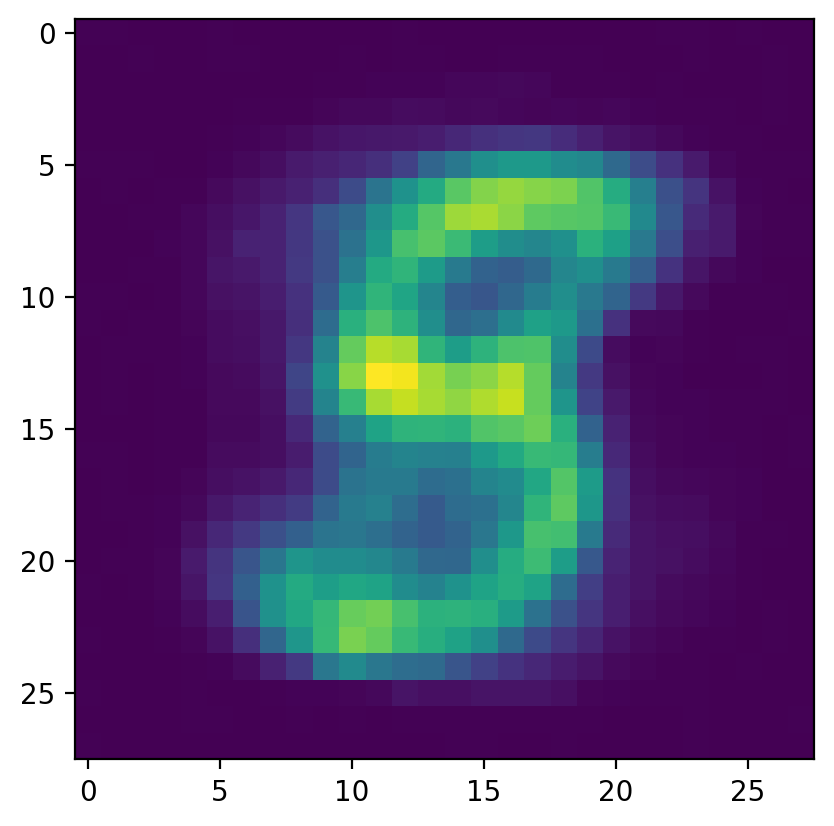

In [ ]:
with torch.no_grad():
  #visualize the true image.
  x,y= next(iter(train_set))
  #print(x.shape)
  plt.imshow(x[0,:,:])
  plt.show()

  #visualize model reconstructions
  x_hat = autoencoder(x)
  #print(x_hat.shape)
  plt.imshow(x_hat[0,0,:,:])
  plt.show()

Now, let's let it train for longer and come back and check again.

In [ ]:
autoencoder, losses = train(autoencoder, train_set, epochs=2)

Step 1000, Loss: 33.6892
Step 2000, Loss: 64.8166
Step 3000, Loss: 40.3903
Step 4000, Loss: 34.8245
Step 5000, Loss: 50.3507
Step 6000, Loss: 27.3978
Step 7000, Loss: 26.4373
Step 8000, Loss: 65.5014
Step 9000, Loss: 25.5694
Step 10000, Loss: 19.1146
Step 11000, Loss: 54.0083
Step 12000, Loss: 42.0893
Step 13000, Loss: 24.5586
Step 14000, Loss: 28.6420
Step 15000, Loss: 18.2056
Step 16000, Loss: 13.4458
Step 17000, Loss: 17.1144
Step 18000, Loss: 32.8886
Step 19000, Loss: 32.8350
Step 20000, Loss: 53.1388
Step 21000, Loss: 34.2175
Step 22000, Loss: 22.3001
Step 23000, Loss: 22.7362
Step 24000, Loss: 41.9995
Step 25000, Loss: 15.8811
Step 26000, Loss: 42.4067
Step 27000, Loss: 29.9249
Step 28000, Loss: 37.1016
Step 29000, Loss: 44.1264
Step 30000, Loss: 14.6036
Step 31000, Loss: 24.1499
Step 32000, Loss: 42.3030
Step 33000, Loss: 40.2531
Step 34000, Loss: 36.7050
Step 35000, Loss: 21.5660
Step 36000, Loss: 31.4921
Step 37000, Loss: 34.7704
Step 38000, Loss: 42.8545
Step 39000, Loss: 30.

<!-- ```{code-cell} ipython3
def train(autoencoder, data, epochs=20):
    results =[]
    opt = torch.optim.Adam(autoencoder.parameters())
    for epoch in range(epochs):
        for x, y in data:
            x = x.to(device) # GPU
            opt.zero_grad()
            
            #model predictions
            x_hat = autoencoder(x)

            #mean squared error loss
            loss = ((x - x_hat)**2).sum()
            loss.backward()
            opt.step()
            results.append(loss)
    return autoencoder
``` -->

## Machine Dreams

Thus far, the network has taken inputs (<b>x</b>), passed those inputs through successive layers to produce ouputs (<b>x'</b>). But, of course, we can think about things that aren't immediately in front of us. We can spontaneously remember our high school friends, think about future dinner plans, imagine events that could never happen, for example: Margaret Thatcher dunking a basketball on Ronald Reagan.


We will consider how minds and machines can generate <b>novel</b> thoughts later in the course. For now, we simply consider: how can neural networks generate new outputs without receiving inputs?

<!-- "Generative model" ---

Discriminative models, by contrast, "discriminate" between different kinds of data instances (using the conditional probability p(y | x)). Generative models generate new data instances. capture the joint probability (p(y,x)).  -->

First, let's directly intervene on the network's thoughts ourselves, intervening on the latent nodes directly.

In [ ]:
def plot_reconstructed(autoencoder, r0=(-5, 10), r1=(-10, 5), n=12):
    w = 28
    img = np.zeros((n*w, n*w))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            #here we actually manipulate the internal activations##
            z = torch.Tensor([[x, y]]).to(device)
            x_hat = autoencoder.Decoder(z)
            x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy()
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat
    plt.imshow(img, extent=[*r0, *r1])

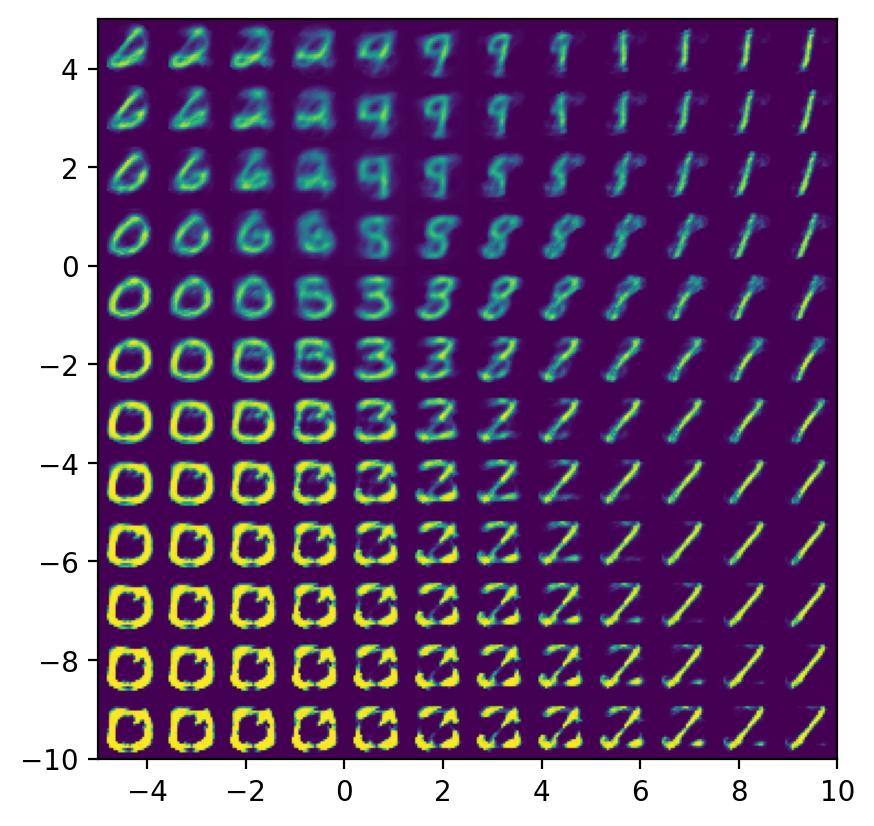

In [ ]:
plot_reconstructed(autoencoder)

These images are generated by uniformly sampling over the possible values, and thus are somewhat arbitrary.

What would this network actually imagine if not prompted? One approach: <i> Compute statistics of the latent nodes, then sample from the resulting probability distribution </i>.

<!--
```{code-cell} ipython3
latent_dims = 2
autoencoder = Autoencoder(latent_dims).to(device)
autoencoder = train(autoencoder, train_set)
``` -->

In [ ]:
import numpy.random as d

latent_size = 2

# Compute statistics of the latent nodes over the FULL dataset
all_z = []
with torch.no_grad():
    for images, labels in train_set:
        images = images.to(device)
        z = autoencoder.Encoder(images)
        all_z.append(z.cpu())

all_z = torch.cat(all_z, dim=0)
print(f'Latent codes shape: {all_z.shape}')

# Define a Multivariate Gaussian using mean and variance of each node
mu = torch.mean(all_z, 0)
v = torch.var(all_z, 0)

m_ = mu.numpy()
v_ = v.numpy()

samples = []
n_samples = 1000

Latent codes shape: torch.Size([60000, 2])


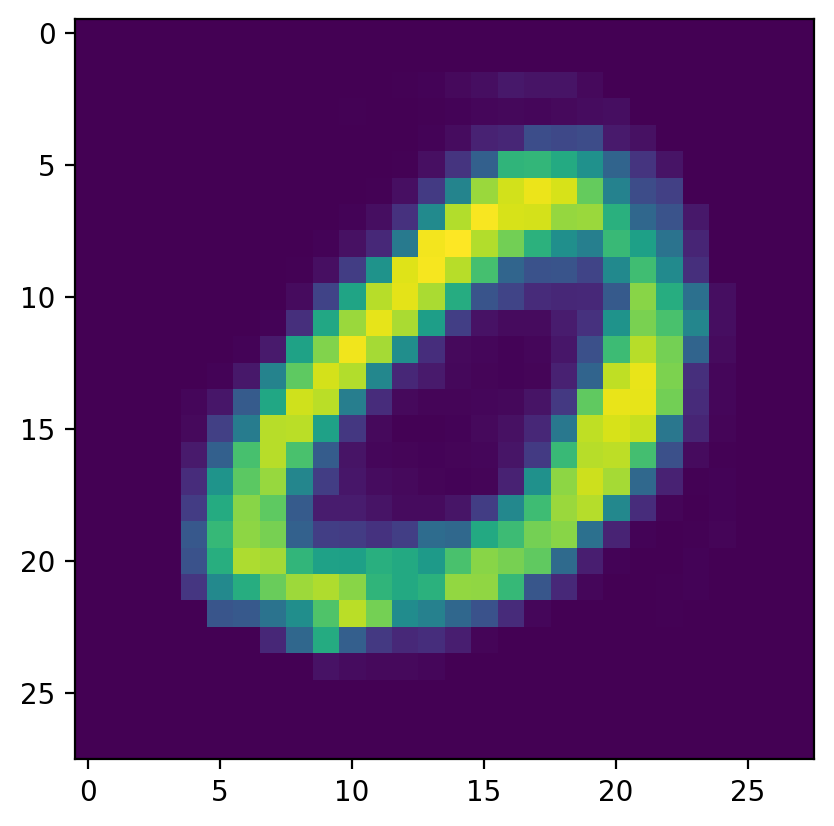

In [ ]:
for i in range(n_samples):
    m = d.multivariate_normal(mean=m_, cov=np.eye(latent_size) * v_)
    samples.append(m)

s = np.array(samples)

# Interpret a sample
z_ = torch.tensor(s[0, :], dtype=torch.float32).to(device)
x_ = autoencoder.Decoder(z_)
x_ = x_.reshape(28, 28).cpu().detach().numpy()
plt.imshow(x_)
plt.show()

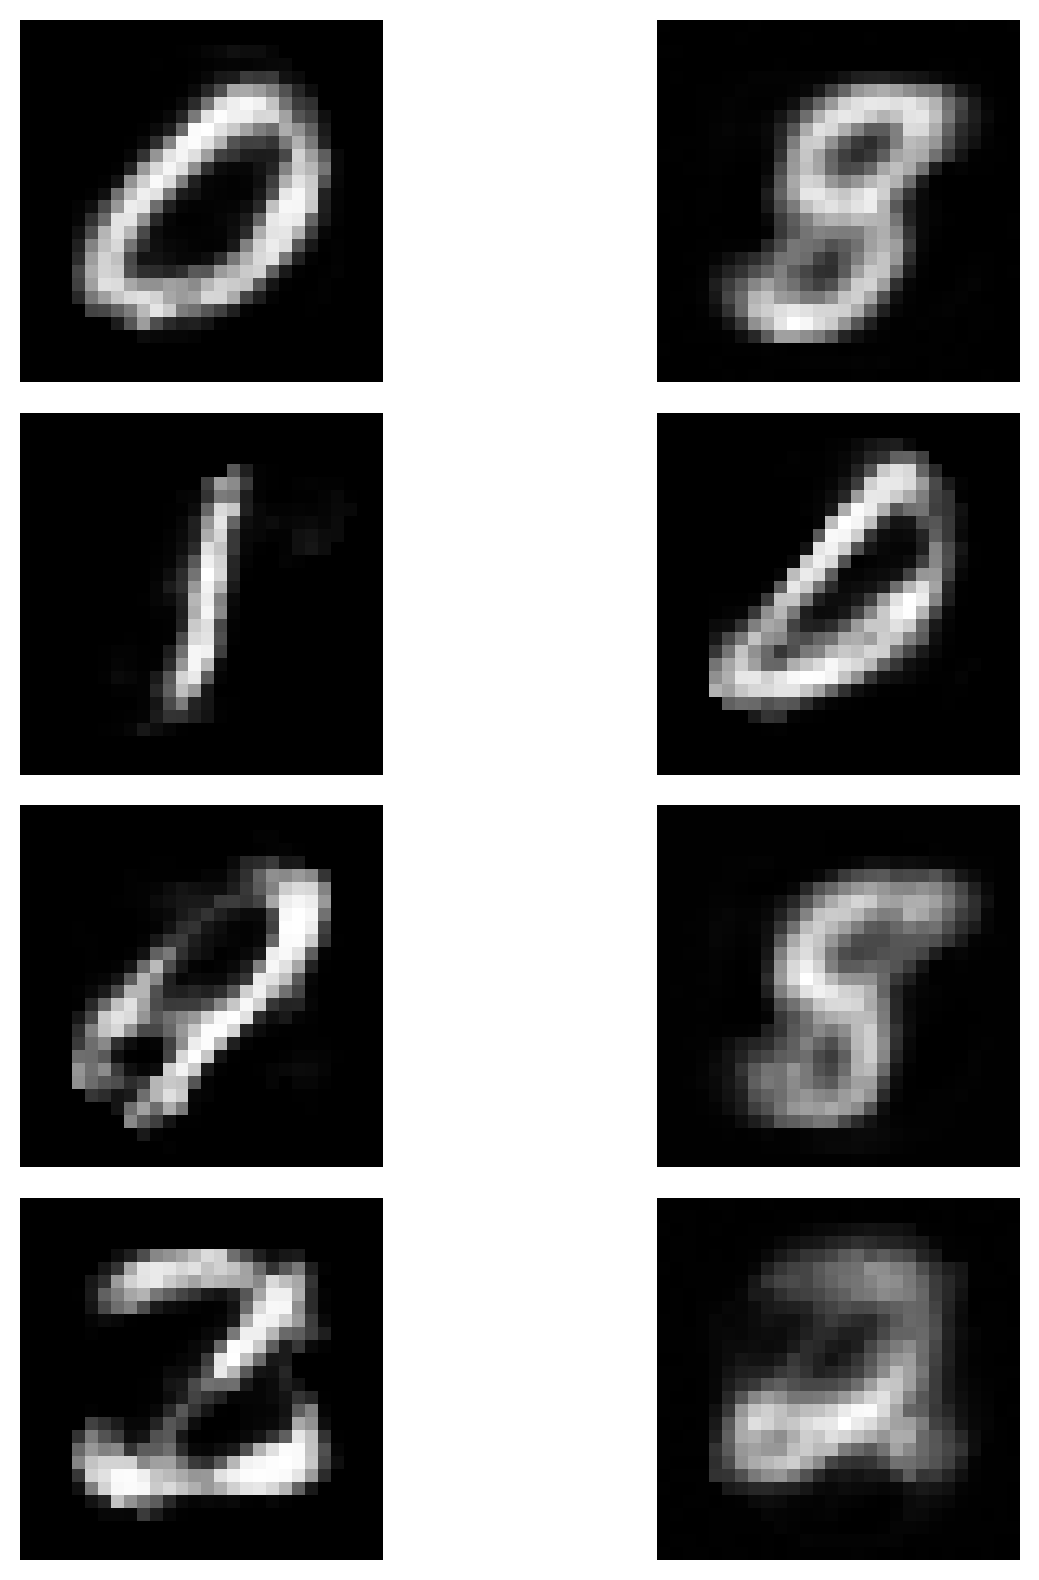

In [ ]:
for i in range(n_samples):
    m = d.multivariate_normal(mean=m_, cov=np.eye(latent_size) * v_)
    samples.append(m)

s = np.array(samples)

# Plot a grid of decoded samples
n_display = 8
fig, axes = plt.subplots(4, 2, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    z_ = torch.tensor(s[i, :], dtype=torch.float32).to(device)
    x_ = autoencoder.Decoder(z_)
    x_ = x_.reshape(28, 28).cpu().detach().numpy()
    ax.imshow(x_, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()



## One of Kahneman and Tversky's Heuristics in a Neural Net

One of the central questions in computational cognitive science is whether the errors humans make can tell us something about the algorithms they're using.

Here's a classic example.

<i> Tom W. attends a university with a large law school (500 students) and a small engineering graduate program (~20 students). Tom W. is of high intelligence, although lacking in true creativity. He has a need for order and clarity, and for neat and tidy systems in which every detail finds its appropriate place. His writing is rather dull and mechanical, occasionally enlivened by somewhat corny puns and by flashes of imagination of the sci-fi type. He has a strong drive for competence. He seems to feel little sympathy for other people and does not enjoy interacting with others. Self-centered, he nonetheless has a deep moral sense.
Do you think it's more likely Tom is attending law school or engineering school? What is the probability of each? </i>


Notice that the <b> base rates </b> here heavily favor law school (500 vs. 20 — a 25-to-1 ratio). A Bayesian reasoner would need very strong evidence from the personality description to overcome that prior. Yet most people confidently say engineering, because the description sounds like an engineer.

This is called base-rate neglect: people ignore how common each category is in the population and instead judge based on how well the description matches their stereotype of each category.

K&T call this this the <b> Representativeness Heuristic </b> -  the "substitution of a (descriptive) similarity judgment for a (normative) probability judgment."


From a normative perspective, the representativeness heuristic is argued to be sub-optimal, leading to several cognitive biases. In addition to base-rate neglect, it has been used to explain the conjunction fallacy and over-confidence in data from small sample sizes.


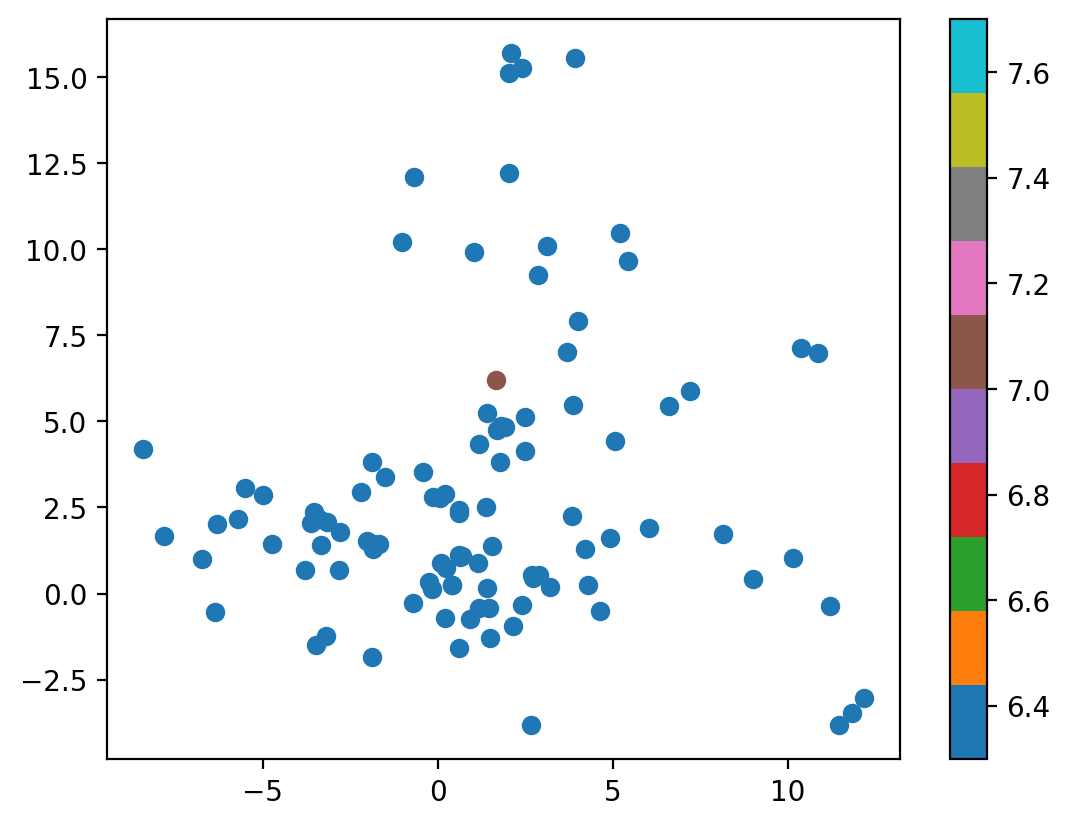

In [ ]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
def plot_latent(autoencoder, data, num_batches=100):
    for i, (x, y) in enumerate(data):
        z = autoencoder.Encoder(x.to(device))
        z = z.to('cpu').detach().numpy()
        plt.scatter(z[:, 0], z[:, 1], c=y, cmap='tab10')
        if i > num_batches:
            plt.colorbar()
            break

plot_latent(autoencoder, train_set)

Neural networks naturally have a representational similarity space (actually, different similarity spaces in each layer), and make "decisions" based on these similarities. How can we model the types of decisions K&T study in a simple neural network?


When the data are drawn from categories, we might be interested in the learned statistical <i> prototype </i>of each category (Rosch, 1975). We can compute the similarity of any example to the centroid of the prototype using <i> inverse distance </i> in a representational space. This distance may differ for different layers of a neural network, depending on what those layers represent.

We can, for example, plot all the 2's in the latent space.

But what does this mean for judgment and decision-making? Smooth, monotonic activation functions naturally treat nearby states as similar. For example, here is the sigmoid activation function.

$$
\sigma(z) = \frac{1} {1 + e^{-z}}
$$


Logistic-curve.svg

The input to each node is a weighted combination of the input vector (activities), passed through a smooth activiation function (filter).

And, as before, we can visualize what smoothly changing a node's value does to "downstream" re-constructions.

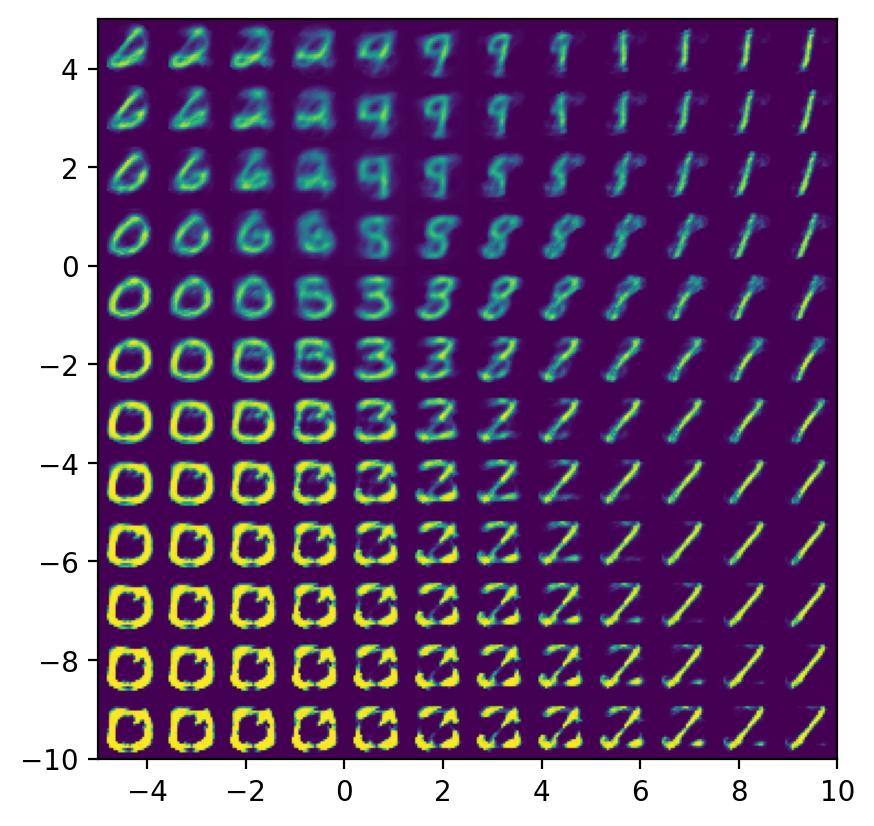

In [ ]:
plot_reconstructed(autoencoder)

This ability to perform similarity-based judgments is critical for the success of Large Language Models (LLMS): when the data are that expansive, and the network that high-dimensional, it's probable that there will be a useful similarity-space somewhere in the network.


Conceptual Questions:

Human can <i>selectively <b>attend</b> to particular latent dimensions </i>? (i.e., features that might be relevant) How might we go about doing this in a neural network?

Is there some way to accomodate Bayesian priors into the neural network's information-processing?


<!-- #### Availability Heuristic

K&T likewise higlighted ways in which the ease with which something comes to mind (incorrectly) influences explicit judgments regarding its probability.

Over the next two weeks we will study memory in physical systems in detail. But we can implement a quick model here.

Imagine we are sampling from the latent space, but the sampling is biased toward particular values, such that some states are retrieved with greater probability.


-frequency
-valence (positive/negative) -->



Connecting this to neural networks: Consider a neural network trained to classify people as "law student" or "engineering student" based on personality descriptions. If the training data reflects the true base rates (500 law students for every 20 engineering students), would you expect the network to show base-rate neglect like human participants do? What if the training data had equal numbers of each? What does this tell us about when a neural network might or might not replicate a human cognitive bias?


## TAKE HOME: A Brief Supervised Category-Learning Problem

We briefly consider the classic supervised learning problem with MNIST, in which the network is given the correct "label" for each image, and tasked with learning the numerical categories ("0", "1", "2", etc.) in preparation for this week's lab assignment.


Let's again import the relevant python functionality.

In [2]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as pl

load MNIST Train and Test data

In [3]:
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(mnist_trainset, batch_size=4, shuffle=True)

mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(mnist_testset, batch_size=4, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 24.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 607kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.04MB/s]


In [4]:
##Define MLP (multi-layer perceptron) class
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.linear1 = nn.Linear(28*28, 50)
        self.linear2 = nn.Linear(50, 25)
        self.final = nn.Linear(25, 10)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid

    def forward(self, img): #convert + flatten
        x = img.view(-1, 28*28)
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.final(x)
        return x
net = Net()

In [5]:
#Make separate even and odd digit testsets to evaluate generalization ability.

mnist_trainset = torchvision.datasets.MNIST('./data', train=True,transform=torchvision.transforms.ToTensor(), download=True)
mnist_testset = torchvision.datasets.MNIST('./data', train=False,transform=torchvision.transforms.ToTensor(), download=True)

from torch.utils.data import Subset, DataLoader

# Define even and odd digits
even_digits = [0, 2, 4, 6, 8]
odd_digits = [1, 3, 5, 7, 9]

# Filter training data for even digits only
even_train_indices = [i for i, (_, label) in enumerate(mnist_trainset) if label in even_digits]
even_train_subset = Subset(mnist_trainset, even_train_indices)
even_train_loader = DataLoader(even_train_subset, batch_size=64, shuffle=True)

odd_train_indices = [i for i, (_, label) in enumerate(mnist_trainset) if label in odd_digits]
odd_train_subset = Subset(mnist_trainset, odd_train_indices)
odd_train_loader = DataLoader(odd_train_subset, batch_size=64, shuffle=True)

# Create two test sets: even and odd
even_test_indices = [i for i, (_, label) in enumerate(mnist_testset) if label in even_digits]
odd_test_indices = [i for i, (_, label) in enumerate(mnist_testset) if label in odd_digits]

even_test_subset = Subset(mnist_testset, even_test_indices)
odd_test_subset = Subset(mnist_testset, odd_test_indices)

even_test_loader = DataLoader(even_test_subset, batch_size=64, shuffle=False)
odd_test_loader = DataLoader(odd_test_subset, batch_size=64, shuffle=False)

In [ ]:
##Define MLP class
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(28*28, 50)
        self.linear2 = nn.Linear(50, 25)
        self.final = nn.Linear(25, 10)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.final(x)
        return x

net = Net()
Xent = nn.CrossEntropyLoss()
#LR how fast do we want the neural network to update it's weights?
optimizer = optim.Adam(net.parameters(), lr=0.001)

#An "Epoch" is 1 complete pass through the entire training dataset
epochs = 5
for epoch in range(epochs):
    for data in even_train_loader:
        x, y = data
        optimizer.zero_grad()
        output = net(x.view(-1, 28*28))
        loss = Xent(output, y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

NameError: name 'optim' is not defined

In [ ]:
#define accuracy function
def evaluate_accuracy(model, dataloader):
    correct = 0
    total = 0
    for data in dataloader:
        x, y = data
        output = model(x.view(-1, 28*28))
        preds = torch.argmax(output, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total


In [ ]:
#test on held out even and odd images.
acc_even = evaluate_accuracy(net, even_test_loader)
acc_odd = evaluate_accuracy(net, odd_test_loader)

## How much data do we need to effectively train the model?

In [ ]:
# Create datasets for training & testing, download if haven't already.

train_set = torchvision.datasets.MNIST('./data', train=True,transform=torchvision.transforms.ToTensor(), download=True)
test_set = torchvision.datasets.MNIST('./data', train=False,transform=torchvision.transforms.ToTensor(), download=True)

# Create data loaders for MNIST datasets; shuffle for training, not for validation
train_load = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True)
test_load = torch.utils.data.DataLoader(test_set, batch_size=16, shuffle=False)

# Report split sizes
print('Training set has {} examples'.format(len(train_set)))
print('Test set has {} examples'.format(len(test_set)))

In [ ]:
from torch.utils.data import Subset
import numpy as np

# Create 3 subsets of increasing size
small_100 = Subset(mnist_trainset, list(range(100)))
medium_1000 = Subset(mnist_trainset, list(range(1000)))
full_60000 = mnist_trainset  # already loaded

# Define DataLoaders
loader_100 = DataLoader(small_100, batch_size=64, shuffle=True)
loader_1000 = DataLoader(medium_1000, batch_size=64, shuffle=True)
loader_60000 = DataLoader(full_60000, batch_size=64, shuffle=True)

def train_model(train_loader, epochs=5):
    model = Net()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

#main loop
    for epoch in range(epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            output = model(x.view(-1, 28*28))
            loss = loss_fn(output, y)
            loss.backward()
            optimizer.step()
    return model

def test_accuracy(model, test_loader):
    correct = 0
    total = 0
    for x, y in test_loader:
        output = model(x.view(-1, 28*28))
        preds = torch.argmax(output, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

##### Train 3 separate models #####
model_100 = train_model(loader_100)
model_1000 = train_model(loader_1000)
model_60000 = train_model(loader_60000)

# Evaluate all on the same test set (e.g., full or even_test_loader)
acc_100 = test_accuracy(model_100, even_test_loader)
acc_1000 = test_accuracy(model_1000, even_test_loader)
acc_60000 = test_accuracy(model_60000, even_test_loader)

print(f"Accuracy (100): {acc_100:.2%}")
print(f"Accuracy (1,000): {acc_1000:.2%}")
print(f"Accuracy (60,000): {acc_60000:.2%}")

import matplotlib.pyplot as plt

training_sizes = [100, 1000, 60000]
accuracies = [acc_100, acc_1000, acc_60000]

plt.plot(training_sizes, accuracies, marker='o')
plt.xscale('log')
plt.xlabel("Training Set Size (log scale)")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs. Training Set Size")
plt.grid(True)
plt.ylim(0, 1)
plt.show()


<!--
## Generalization


Let us first consider the problem of "interpolation."


```{code-cell}
def interpolate(autoencoder, x_1, x_2, n=12):
    z_1 = autoencoder.encoder(x_1)
    z_2 = autoencoder.encoder(x_2)
    z = torch.stack([z_1 + (z_2 - z_1)*t for t in np.linspace(0, 1, n)])
    interpolate_list = autoencoder.decoder(z)
    interpolate_list = interpolate_list.to('cpu').detach().numpy()

    #plot the results
    w = 28
    img = np.zeros((w, n*w))
    for i, x_hat in enumerate(interpolate_list):
        img[:, i*w:(i+1)*w] = x_hat.reshape(28, 28)
    
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
  ```
 -->




<!-- ## Implementation: Arrays and Tensors -->



<!-- # Loss Functions

```{Note}

Here, we discuss some common mathematical expressions for quantifying "loss" so we can build neural networks, but for the human mind what variables should these loss functions ref lect and when? Elaborate and defend either a "modular view", a "common currency" view, or some combination thereof.


``` -->

<!-- Some common realizations.

Mean Squared Error

$$
  \sum_{i=1}^{k}(y_i - \hat{y}_i)^2
$$

Mean Absolute Error

$$
 \sum_{i=1}^{D}|x_i-y_i|
$$


Cross-Entropy

$$
 -\sum_{c=1}^My_{o,c}\log(p_{o,c})
$$


KL-divergence

Meausure of the similarity between two probability distribution p and q. Unlike some similarity measures, Dkl is asymmetric. Here, we treat p as the target distribution and q model's output distribution.

$$
D_{KL}(P||Q)=\sum_{x}P(x)\log(\frac{P(x)}{Q(x)})
$$


First, we <i>import </i> some needed functionality.




## Some Basic Activation Functions

f (Wx+b)

Linear

Step (?)
Differentiability.

Sigmoid

$$
\sigma(z) = \frac{1} {1 + e^{-z}}
$$

ReLu

Softmax

$$
\sigma(z_i) = \frac{e^{z_{i}}}{\sum_{j=1}^K e^{z_{j}}} \ \ \ for\ i=1,2,\dots,K
$$

 -->